# Open WOD datasets

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw

### Plot vars

In [7]:
# ctd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/APB/*.nc')
ctd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/CTD/*.nc')

In [ ]:
ctd_ds.time.values

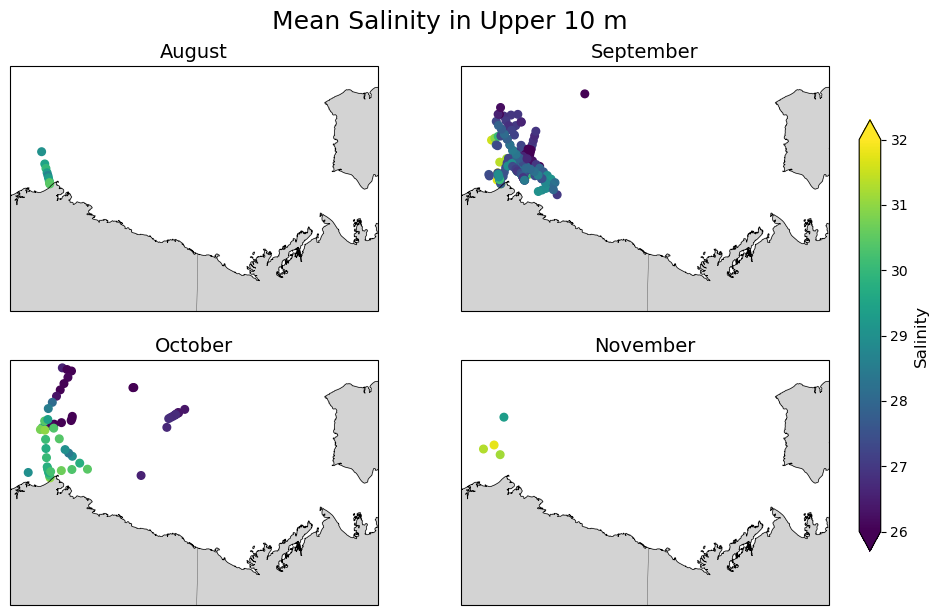

In [9]:
# months you want to plot
months = [8, 9, 10, 11]
month_names = {8: "August", 9: "September", 10: "October", 11: "November"}

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, axes = plt.subplots(2, 2, figsize=(13, 7),
                         subplot_kw={'projection': proj})

axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, month in zip(axes, months):

    # set map extent
    ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())

    # add isobaths
    # bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    # gridlines (no labels)
    # gl = ax.gridlines(draw_labels=False, dms=True,
    #                   x_inline=False, y_inline=False)

    # subset each dataset by month
    apb_m = ctd_ds.where(ctd_ds.time.dt.month == month, drop=True)

    # SCATTER PLOTS (capturing the last one for colorbar)
    sc = ax.scatter(
        apb_m.lon, apb_m.lat, s=30,
        c=apb_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{month_names[month]}", fontsize=14)
    
fig.suptitle("Mean Salinity in Upper 10 m          ", fontsize=18, y=0.96)

cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("Salinity", fontsize=12)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

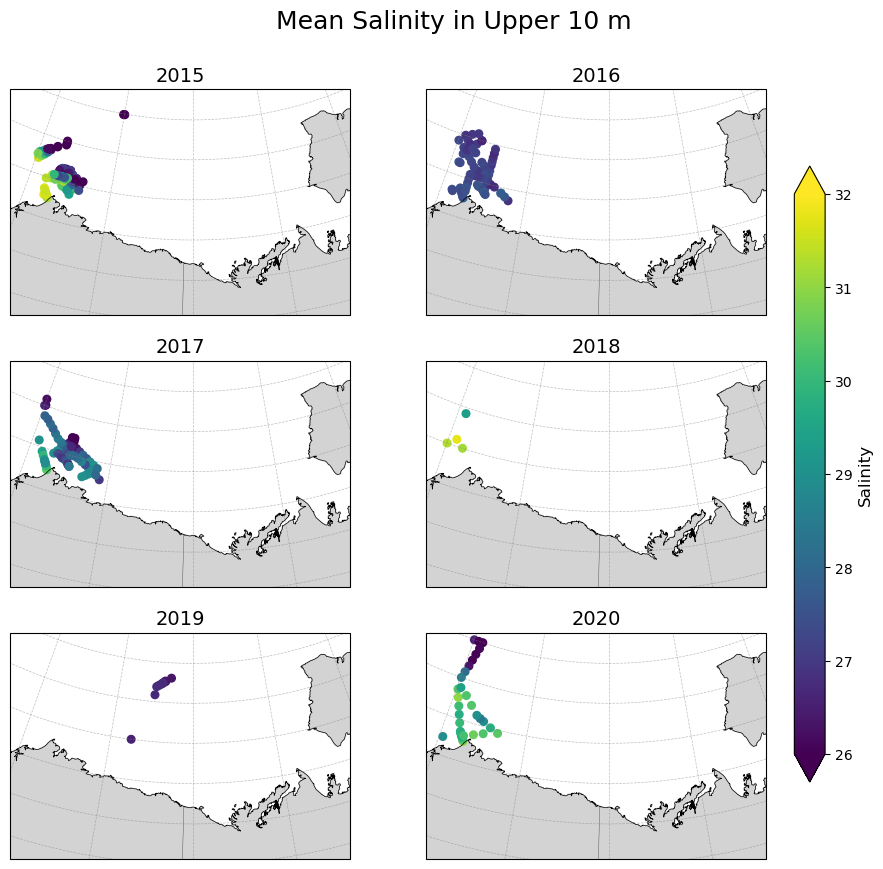

In [21]:
# years to plot
years = [2015, 2016, 2017, 2018, 2019, 2020]

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

# create 3x2 grid for 6 years
fig, axes = plt.subplots(3, 2, figsize=(12, 10), subplot_kw={'projection': proj})
axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, year in zip(axes, years):

    # set map extent
    ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'fontsize': 10}
    gl.ylabel_style = {'fontsize': 10}
    
    # subset dataset by year
    apb_y = ctd_ds.sel(time=ctd_ds.time.dt.year == year)

    # SCATTER PLOTS (mean salinity in upper 10 m)
    sc = ax.scatter(
        apb_y.lon, apb_y.lat, s=30,
        c=apb_y.Salinity.sel(z=slice(0, 10)).mean('z'),
        vmin=26, vmax=32,
        transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{year}", fontsize=14)

# overall figure title
fig.suptitle("Mean Salinity in Upper 10 m", fontsize=18, y=0.96)

# colorbar
cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("Salinity", fontsize=12)

plt.show()

In [44]:
ctd_2020_west.time.values

array(['2020-10-09T13:06:00.001373184', '2020-10-09T19:24:59.995994112',
       '2020-10-09T19:42:00.004463616', '2020-10-09T19:59:00.002631680',
       '2020-10-09T20:22:00.000457728', '2020-10-09T20:44:59.998283776',
       '2020-10-09T21:00:00.000000000', '2020-10-09T21:15:00.001716224',
       '2020-10-09T21:29:00.002631680', '2020-10-09T21:43:59.999199232',
       '2020-10-09T23:22:00.000457728', '2020-10-10T01:00:00.000107520',
       '2020-10-10T02:37:59.999757312', '2020-10-10T04:16:59.999885312',
       '2020-10-10T05:52:00.000028672', '2020-10-11T16:00:59.997368320',
       '2020-10-11T17:09:00.000343040', '2020-10-13T05:50:00.001001472',
       '2020-10-13T08:26:59.999312896', '2020-10-13T11:10:00.001144832',
       '2020-10-13T13:43:00.000114688', '2020-10-13T16:10:59.995078656',
       '2020-10-13T18:01:59.996451840', '2020-10-13T19:21:59.998741504',
       '2020-10-14T00:32:00.000046080', '2020-10-14T03:16:59.999456256',
       '2020-10-14T07:48:59.999770624', '2020-10-15

In [112]:
# below 73.5 and west of 150
ctd_2020_west = ctd_ds.where(ctd_ds.lat<73,drop=True).where(ctd_ds.lon<150,drop=True).sel(time='2020')

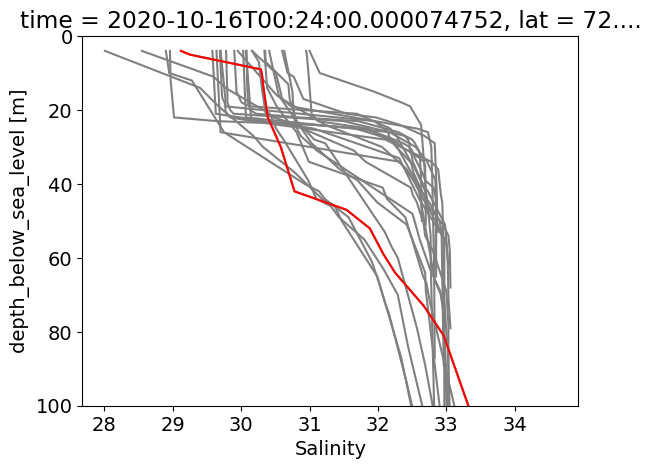

In [120]:
ctd_2020_west.Salinity.plot(y='z',hue='time',c='gray',add_legend=False)
ctd_2020_west.isel(time=20).Salinity.plot(y='z',c='r',add_legend=False)
plt.ylim(100,0);

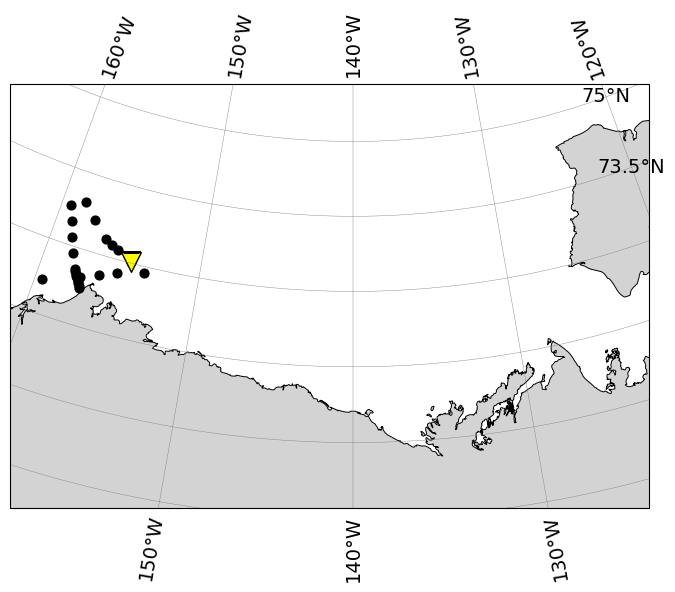

In [122]:
plt.rcParams['font.size'] = 14

# --- projection and figure ---
proj = ccrs.NorthPolarStereo(central_longitude=-140)
fig, ax = plt.subplots(1, 1, figsize=(7, 6), subplot_kw={'projection': proj})

ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray')
# add isobaths
# bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# --- left: colored by max depth ---
sc1 = ax.scatter(
    ctd_2020_west.lon, ctd_2020_west.lat,c='k',
    s=40,
    transform=ccrs.PlateCarree()
)
i = 20
ax.scatter(ctd_2020_west.isel(time=i).lon, ctd_2020_west.isel(time=i).lat, marker='v', color='yellow', edgecolor='k', s=200,transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

In [126]:
def compute_mld_profiles(apb_ds, rho_thresh=0.1):
    """
    Compute mixed layer depth using a 0.1 kg/m^3 density threshold.
    Uses z (m, positive downward) instead of pressure.
    
    Parameters
    ----------
    apb_ds : xarray.Dataset
        Must include:
        - Salinity(time, z)
        - Temperature(time, z)
        - z (m, positive downward)
        - Latitude(time)
        - Longitude(time)
    rho_thresh : float
        Density increase threshold (kg/m^3).
    
    Returns
    -------
    xarray.DataArray of MLD (time).
    """

    # Convert depth (m) → pressure (dbar)
    pressure = apb_ds.z  # 1 m ≈ 1 dbar

    # Broadcast latitude + longitude to match (time, z)
    lat2d = apb_ds.lat.broadcast_like(apb_ds.Salinity)
    lon2d = apb_ds.lon.broadcast_like(apb_ds.Salinity)

    # Compute Absolute Salinity and Conservative Temperature
    SA = gsw.SA_from_SP(apb_ds.Salinity, pressure, lon2d, lat2d)
    CT = gsw.CT_from_t(SA, apb_ds.Temperature, pressure)

    # Compute density (kg/m^3)
    rho = gsw.rho(SA, CT, pressure)

    mld_list = []

    # Loop profiles
    for t in apb_ds.time:
        rho_profile = rho.sel(time=t)
        depth_profile = apb_ds.z  # same for all times

        # reference density at **uppermost valid measurement**
        valid_idx = np.where(~np.isnan(rho_profile.values))[0]
        if len(valid_idx) == 0:
            mld_list.append(np.nan)
            continue

        rho0 = rho_profile.isel(z=valid_idx[0]).values

        # density anomaly relative to surface
        drho = rho_profile - rho0

        # first z where drho >= threshold
        idx = np.argmax(drho.values >= rho_thresh)

        if drho[idx] >= rho_thresh:
            mld = depth_profile.isel(z=idx).item()
        else:
            mld = np.nan  # no mixed layer depth found

        mld_list.append(mld)

    # Return as DataArray
    return xr.DataArray(
        mld_list,
        coords={'time': apb_ds.time},
        dims=['time'],
        name='MLD',
        attrs={'units': 'm', 'long_name': 'Mixed Layer Depth (0.1 kg/m^3 threshold)'}
    )

In [128]:
ctd_2020_west_mld = compute_mld_profiles(ctd_2020_west, rho_thresh=0.1)

In [130]:
ctd_2020_west_mld

<xarray.DataArray 'MLD' (time: 24)> Size: 192B
array([19,  8, 11,  7, 17, 19, 19, 18, 16, 19, 20, 16, 19, 16, 16, 10,  8,
       12,  6, 12,  5, 11,  5,  5])
Coordinates:
  * time     (time) datetime64[ns] 192B 2020-10-09T13:06:00.001373184 ... 202...
Attributes:
    units:      m
    long_name:  Mixed Layer Depth (0.1 kg/m^3 threshold)

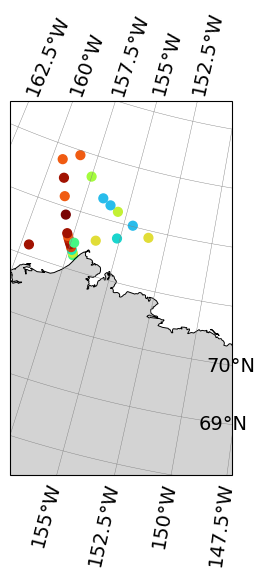

In [146]:
plt.rcParams['font.size'] = 14

# --- projection and figure ---
proj = ccrs.NorthPolarStereo(central_longitude=-140)
fig, ax = plt.subplots(1, 1, figsize=(7, 6), subplot_kw={'projection': proj})

ax.set_extent([-157.5, -150, 68, 74], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray')
# add isobaths
# bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# --- left: colored by max depth ---
sc1 = ax.scatter(
    ctd_2020_west.lon, ctd_2020_west.lat,c=ctd_2020_west_mld,
    s=40,vmin=0,vmax=20,cmap='turbo',
    transform=ccrs.PlateCarree()
)
plt.tight_layout()
plt.show()

In [150]:
ctd_mld = compute_mld_profiles(ctd_ds, rho_thresh=0.1)

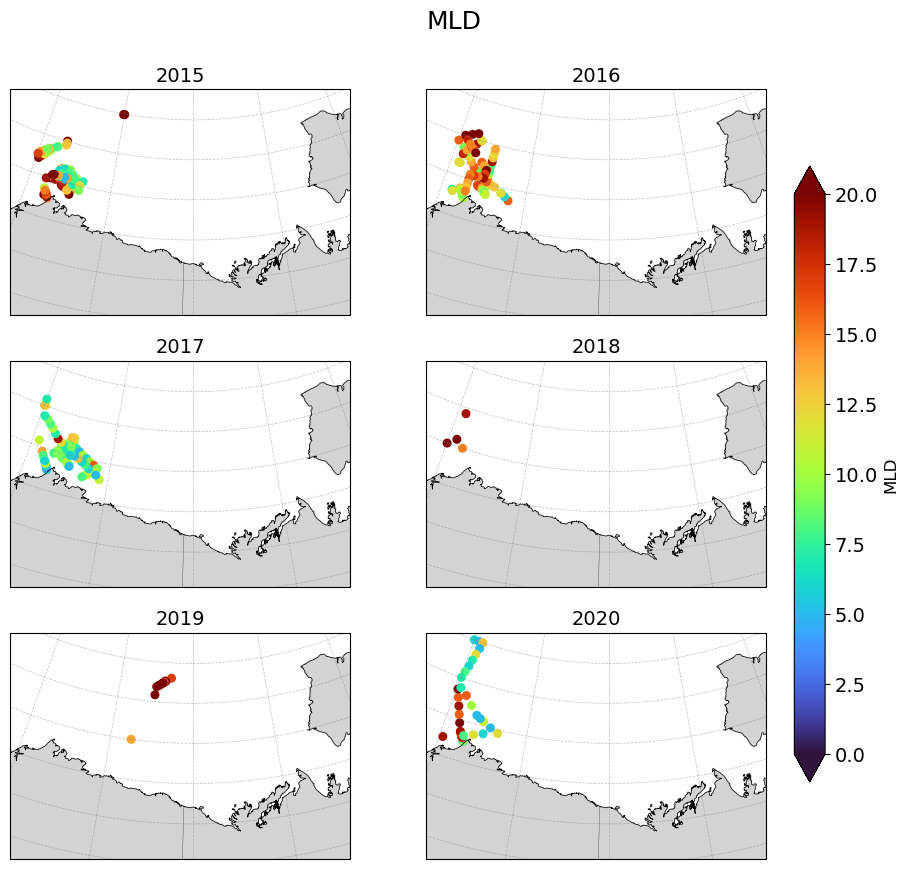

In [164]:
# years to plot
years = [2015, 2016, 2017, 2018, 2019, 2020]

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

# create 3x2 grid for 6 years
fig, axes = plt.subplots(3, 2, figsize=(12, 10), subplot_kw={'projection': proj})
axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, year in zip(axes, years):

    # set map extent
    ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'fontsize': 10}
    gl.ylabel_style = {'fontsize': 10}
    
    # subset dataset by year
    ctd_y = ctd_ds.sel(time=ctd_ds.time.dt.year == year)
    ctd_mld_y = ctd_mld.sel(time=ctd_mld.time.dt.year == year)

    # SCATTER PLOTS (mean salinity in upper 10 m)
    sc = ax.scatter(
        ctd_y.lon, ctd_y.lat, s=30,
        c=ctd_mld_y,
        vmin=0, vmax=20,cmap='turbo',
        transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{year}", fontsize=14)

# overall figure title
fig.suptitle("MLD", fontsize=18, y=0.96)

# colorbar
cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("MLD", fontsize=12)

plt.show()

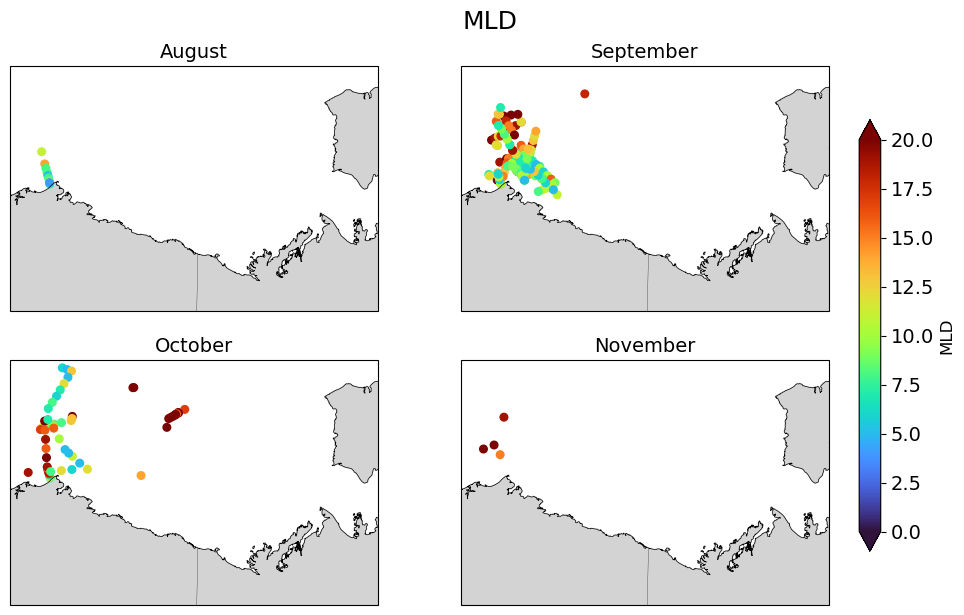

In [162]:
# months you want to plot
months = [8, 9, 10, 11]
month_names = {8: "August", 9: "September", 10: "October", 11: "November"}

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, axes = plt.subplots(2, 2, figsize=(13, 7),
                         subplot_kw={'projection': proj})

axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, month in zip(axes, months):

    # set map extent
    ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())

    # add isobaths
    # bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    # gridlines (no labels)
    # gl = ax.gridlines(draw_labels=False, dms=True,
    #                   x_inline=False, y_inline=False)

    # subset each dataset by month
    ctd_m = ctd_ds.where(ctd_ds.time.dt.month == month, drop=True)
    ctd_mld_m = ctd_mld.where(ctd_mld.time.dt.month == month, drop=True)

    # SCATTER PLOTS (capturing the last one for colorbar)
    sc = ax.scatter(
        ctd_m.lon, ctd_m.lat, s=30,
        c=ctd_mld_m,cmap='turbo',
        vmin=0, vmax=20, transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{month_names[month]}", fontsize=14)
    
fig.suptitle("MLD", fontsize=18, y=0.96)

cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("MLD", fontsize=12)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()